# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [176]:
temperaturas = pd.read_csv("data/temps.csv")

### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [177]:
temperaturas.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


In [178]:
temperaturas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    object 
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 24.6+ KB


In [179]:
temperaturas['actual'].value_counts()

actual
57    16
60    16
68    16
65    13
71    12
55    12
52    11
67    11
59    11
64    11
77    10
51    10
63     9
75     9
49     9
76     9
66     9
53     8
61     8
54     8
48     8
73     8
58     7
56     7
74     7
79     6
81     6
62     6
40     6
69     5
80     5
72     5
44     4
85     4
46     4
45     4
70     4
50     4
41     3
82     3
39     3
42     3
47     2
35     2
87     2
78     2
83     2
89     1
86     1
92     1
88     1
84     1
90     1
43     1
36     1
Name: count, dtype: int64

In [180]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [181]:
temperaturas['week_encoded'] = encoder.fit_transform(temperaturas['week'])
temperaturas

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_encoded
0,2016,1,1,Fri,45,45,45.6,45,29,0
1,2016,1,2,Sat,44,45,45.7,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,56,3
3,2016,1,4,Mon,44,41,45.9,40,53,1
4,2016,1,5,Tues,41,40,46.0,44,41,5
...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47,5
344,2016,12,28,Wed,42,47,45.3,48,58,6
345,2016,12,29,Thurs,47,48,45.3,48,65,4
346,2016,12,30,Fri,48,48,45.4,57,42,0


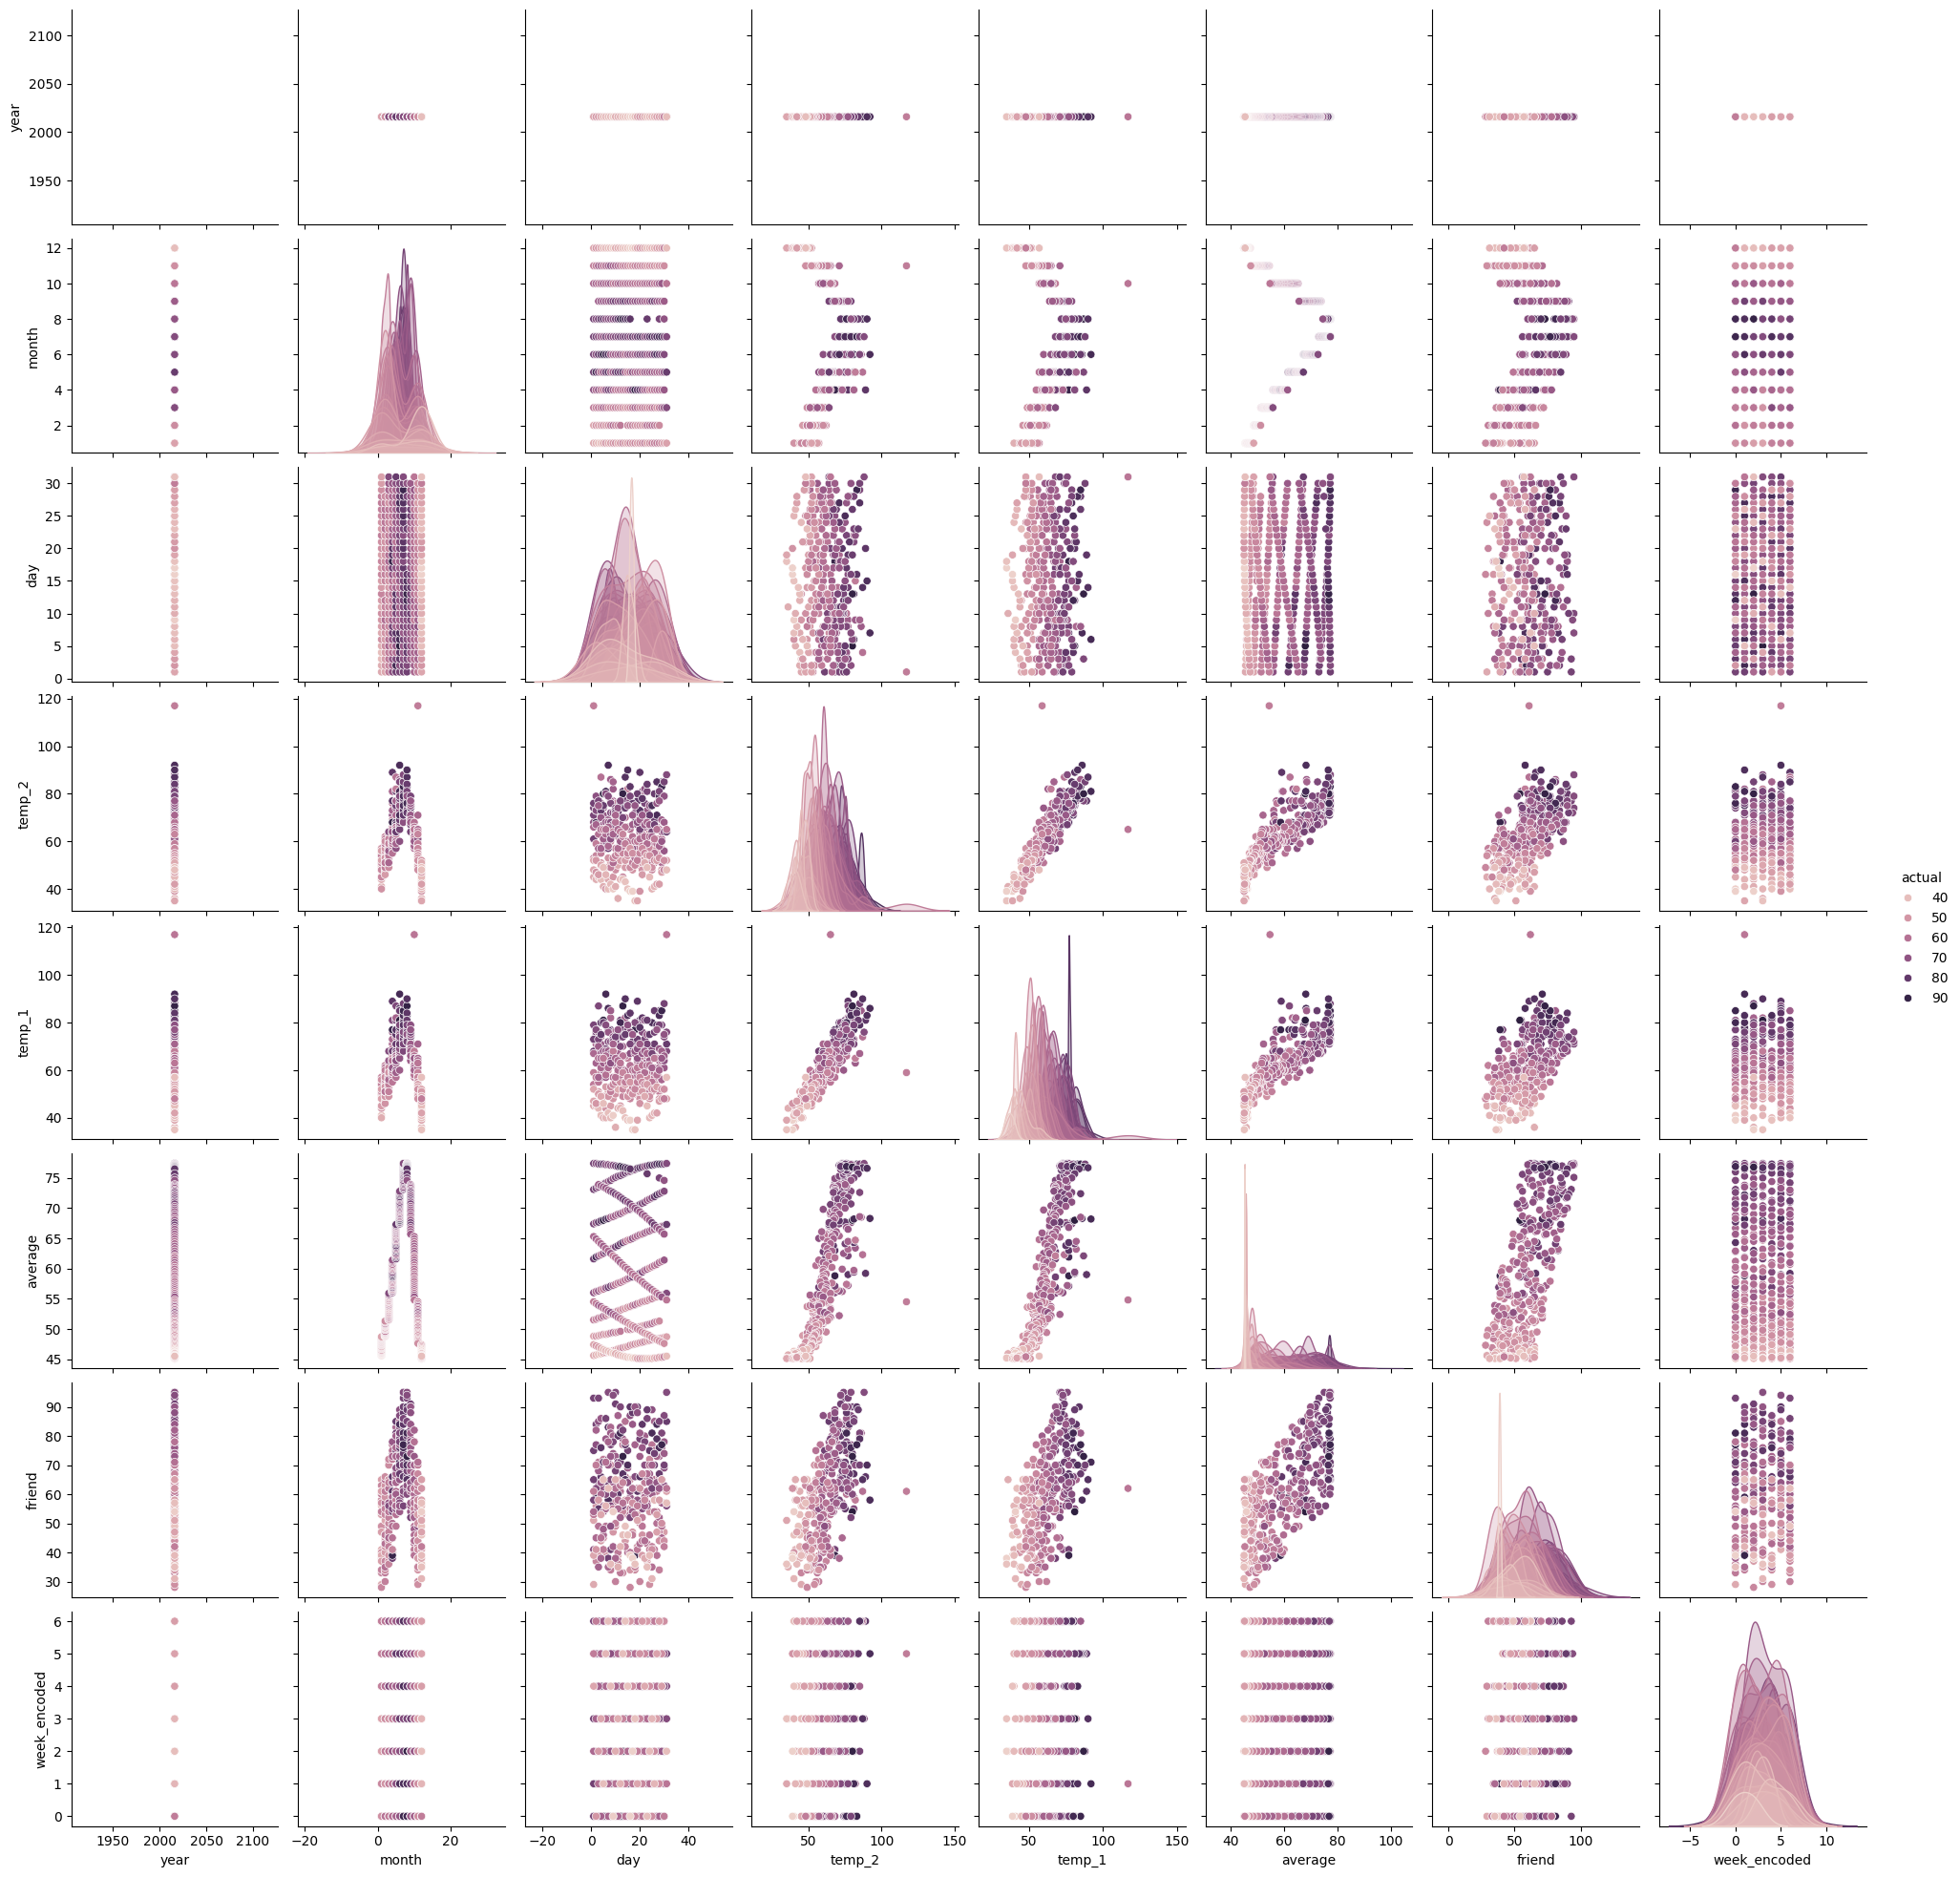

In [182]:
sns.pairplot(temperaturas, hue='actual')

<Axes: >

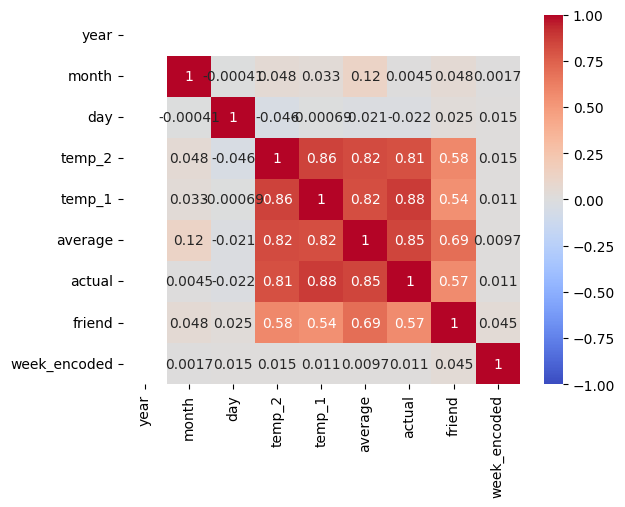

In [183]:
sns.heatmap(temperaturas.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

Quitamos temp_2 y las que no tienen correlacion

No quitamos nada ya que a los arboles de decisión les da igual

### 3. Selecciona variables y divide en train y test

In [184]:
temperaturas.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'week_encoded'],
      dtype='object')

In [185]:
X = temperaturas[['year', 'month', 'day', 'temp_2', 'temp_1', 'average',
       'friend', 'week_encoded']]
y = temperaturas['actual']

In [186]:
from sklearn.model_selection import train_test_split

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [188]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 8)
(70, 8)
(278,)
(70,)


### 4. Entrena el modelo


DecisionTreeClassifier NO, hay que usar el de regresion

In [189]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [190]:
predictions = tree_reg.predict(X_test)

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [191]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [192]:
print("R2 test", r2_score(y_test, predictions))
print("MAE test", mean_absolute_error(y_test, predictions))
print("MAPE test", mean_absolute_percentage_error(y_test, predictions))
print("MSE test", mean_squared_error(y_test, predictions))
print("RMSE test", np.sqrt(mean_squared_error(y_test, predictions)))

R2 test 0.7164829583270087
MAE test 4.7
MAPE test 0.07453287465803331
MSE test 39.642857142857146
RMSE test 6.296257391725432


### 6. Representa el árbol de decisión

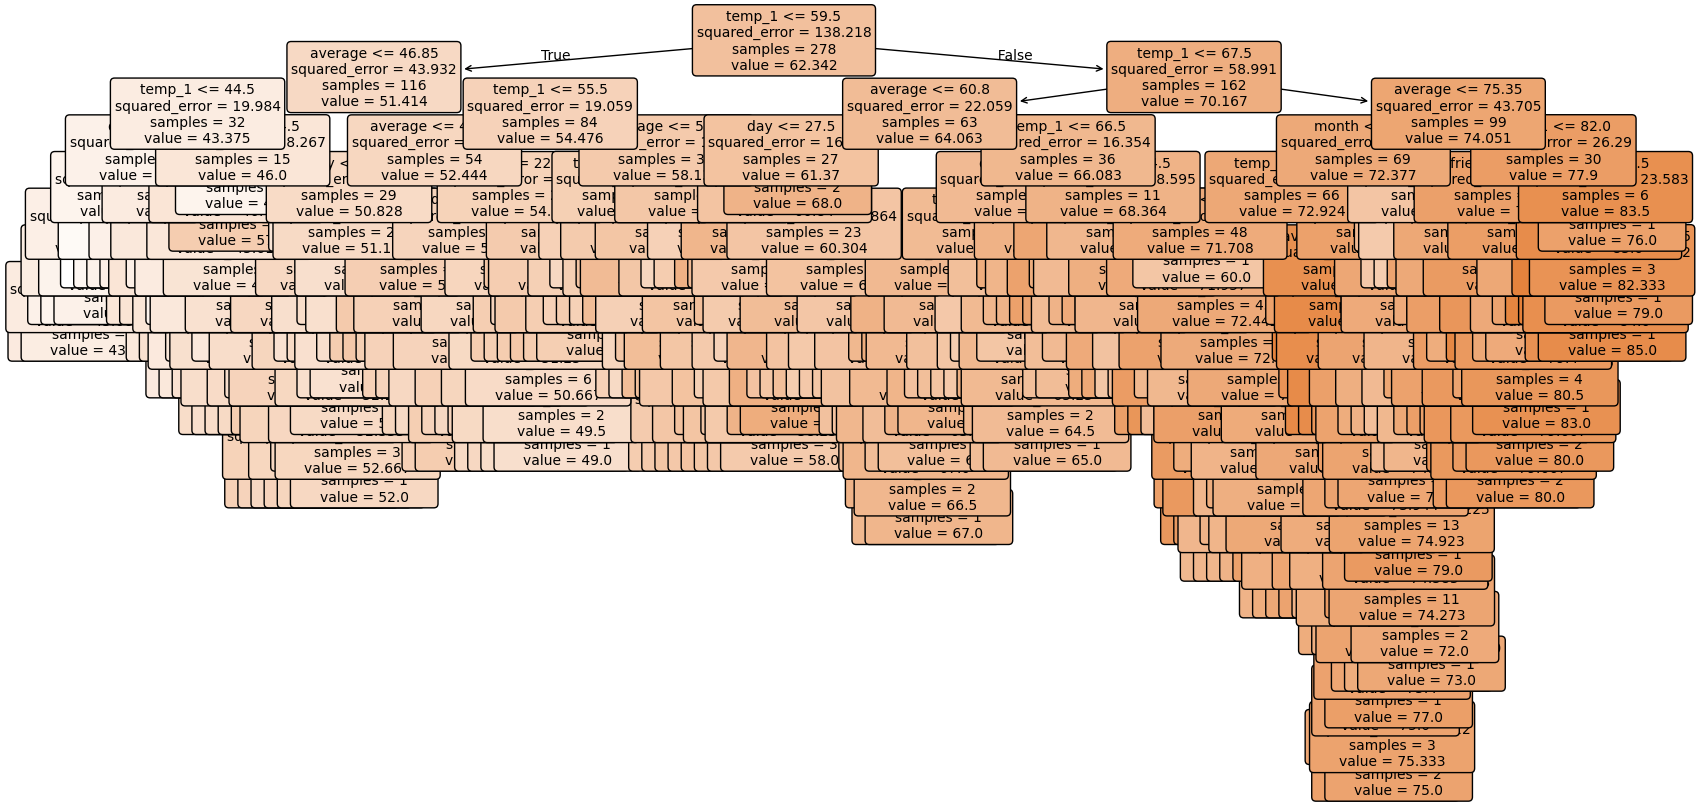

In [193]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [194]:
tree_reg_3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg_3.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [195]:
pred_3 = tree_reg_3.predict(X_test)

### 8. Vuelve a evaluar tu modelo

In [196]:
print("R2 test", r2_score(y_test, pred_3))
print("MAE test", mean_absolute_error(y_test, pred_3))
print("MAPE test", mean_absolute_percentage_error(y_test, pred_3))
print("MSE test", mean_squared_error(y_test, pred_3))
print("RMSE test", np.sqrt(mean_squared_error(y_test, pred_3)))

R2 test 0.7786776796296856
MAE test 4.267242249556827
MAPE test 0.0674392768128964
MSE test 30.946461197509944
RMSE test 5.5629543587476915


### 9. Vuelve a representar su árbol

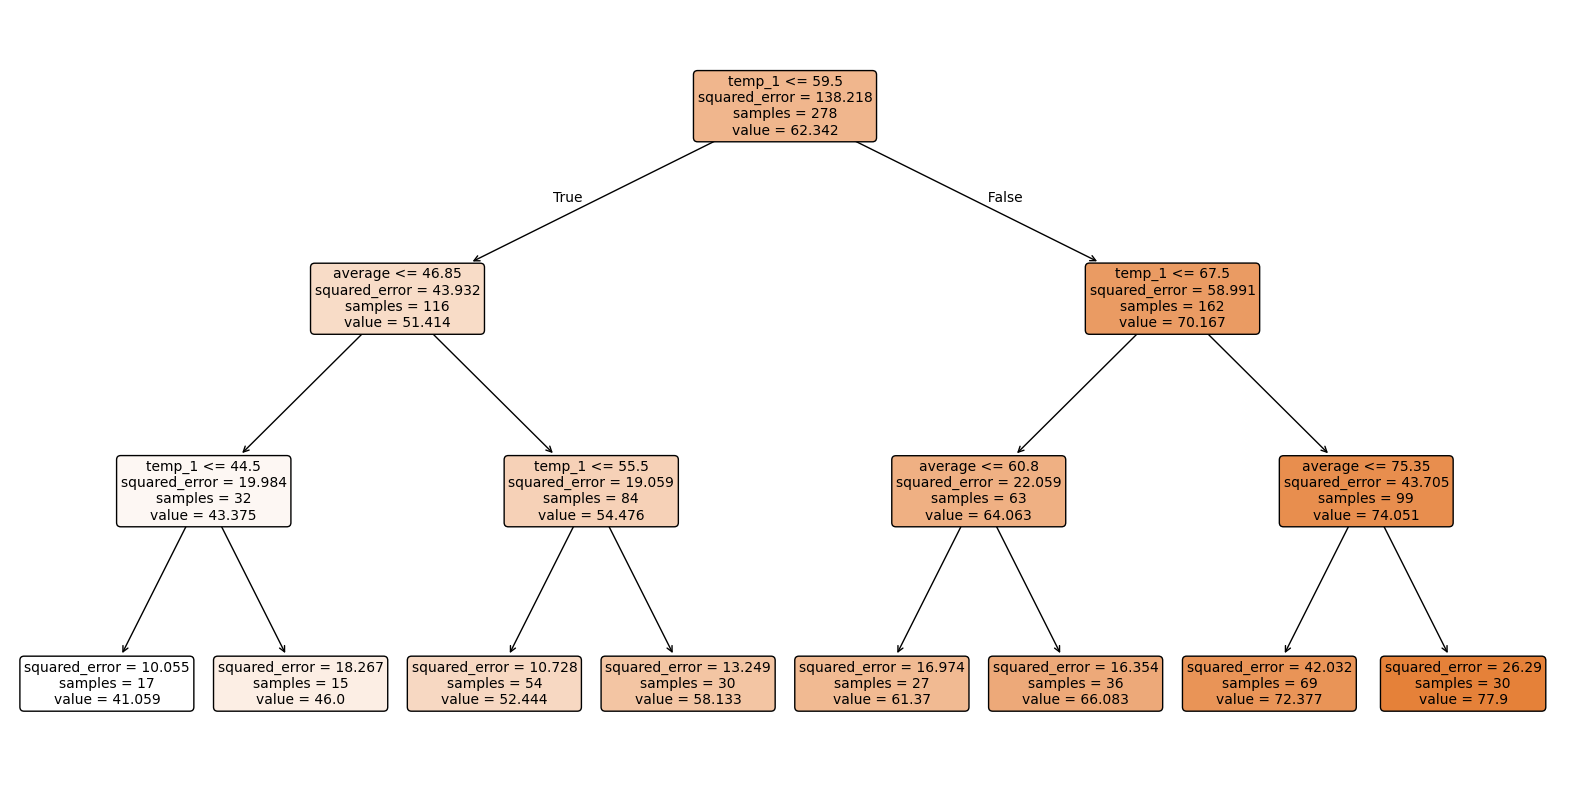

In [197]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_reg_3,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [198]:
from sklearn.model_selection import GridSearchCV

In [199]:
param_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [200]:
grid_search = GridSearchCV(
    estimator=tree_reg,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor score (CV):", grid_search.best_score_)

Mejores hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score (CV): -30.288951382678324


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [201]:
importances = tree_reg_3.feature_importances_

In [202]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp


,feature,importance
4,temp_1,0.881109
5,average,0.118891
0,year,0.000000
1,month,0.000000
3,temp_2,0.000000
2,day,0.000000
6,friend,0.000000
7,week_encoded,0.000000


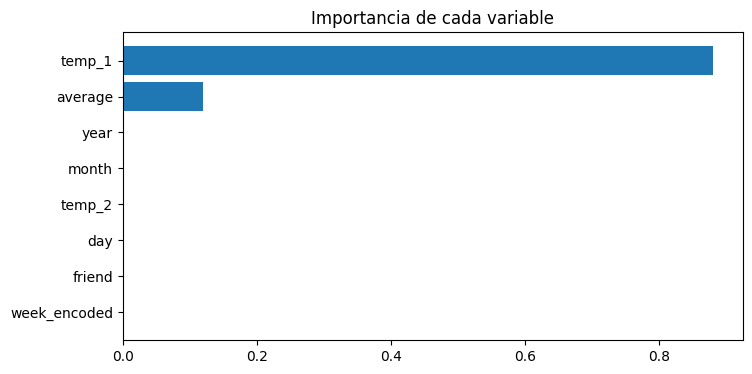

In [203]:
plt.figure(figsize=(8,4))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Importancia de cada variable")
plt.show()


### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [226]:
y_class = (temperaturas['actual'] > 59)  # 1 si > 59ºF, 0 si no

In [227]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [228]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

param_grid_clf = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search_clf = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_clf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_clf.fit(X_train_c, y_train_c)

print("Mejores hiperparámetros:", grid_search_clf.best_params_)
print("Mejor score CV:", grid_search_clf.best_score_)


Mejores hiperparámetros: {'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
Mejor score CV: 0.8885714285714286


In [229]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

best_clf = grid_search_clf.best_estimator_

y_pred_c = best_clf.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c))
print("Recall:", recall_score(y_test_c, y_pred_c))
print("F1:", f1_score(y_test_c, y_pred_c))

print("\nMatriz de confusión:\n", confusion_matrix(y_test_c, y_pred_c))
print("\nClassification report:\n", classification_report(y_test_c, y_pred_c))


Accuracy: 0.8571428571428571
Precision: 0.8809523809523809
Recall: 0.8809523809523809
F1: 0.8809523809523809

Matriz de confusión:
 [[23  5]
 [ 5 37]]

Classification report:
               precision    recall  f1-score   support

       False       0.82      0.82      0.82        28
        True       0.88      0.88      0.88        42

    accuracy                           0.86        70
   macro avg       0.85      0.85      0.85        70
weighted avg       0.86      0.86      0.86        70



In [230]:
temperaturas[temperaturas["actual"] < 40]

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_encoded
325,2016,12,9,Fri,40,41,46.0,36,54,0
330,2016,12,14,Wed,43,40,45.4,39,49,6
331,2016,12,15,Thurs,40,39,45.3,39,46,4
332,2016,12,16,Fri,39,39,45.3,35,39,0
333,2016,12,17,Sat,39,35,45.2,35,38,2
334,2016,12,18,Sun,35,35,45.2,39,36,3
